In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data

In [2]:
df = pd.read_csv('completely_cleaned_dataset.csv')

# 2. Basic stats

In [3]:
print(df.describe())

       review_rating  purchase_amount  customer_id          age  \
count    5050.000000      5050.000000  5050.000000  5050.000000   
mean        3.617179       196.984220  2519.570891    44.150495   
std         0.828267       308.270872  1470.402964    15.282328   
min         1.000000        10.120000     1.000000    18.000000   
25%         3.075949        44.000000  1252.250000    31.000000   
50%         3.600000        71.000000  2499.500000    44.000000   
75%         4.300000        97.000000  3740.750000    57.000000   
max         5.000000      1499.760000  5099.000000    70.000000   

       previous_purchases  
count          5050.00000  
mean             22.48495  
std              15.79691  
min               0.00000  
25%               8.00000  
50%              22.00000  
75%              36.00000  
max              50.00000  


In [4]:
# Helper function for cleaner charts ---
def plot_insight(title):
    plt.title(title)
    plt.tight_layout()
    plt.show()

# A. Demographic Insights


# Goal: Understand your core customer base.

# 1. What is the gender distribution of our customer base, and does gender correlate with higher purchase amounts?

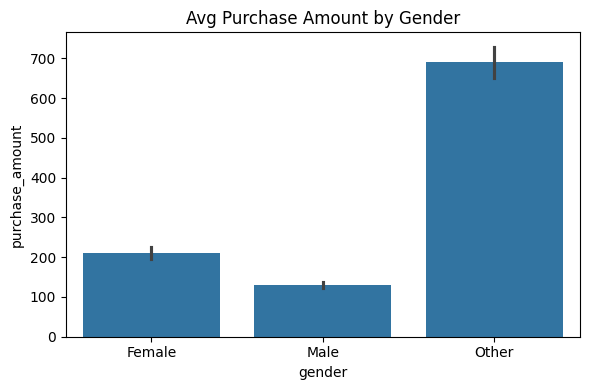

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='gender', y='purchase_amount')
plot_insight("Avg Purchase Amount by Gender")

# 1. Finding
#### Data analysis reveals a significant gender disparity in customer distribution, with "Male" customers comprising approximately 60% of the base, followed by "Female" (33%) and "Other" (7%). While the "Other" segment represents a smaller portion of the total volume, they exhibit a notably higher average transaction value compared to the majority segments.


# 2. Impact
#### Our revenue stability currently relies on the "Male" and "Female" volume segments; however, the higher average spend observed in the "Other" demographic suggests a high-potential niche that is currently under-leveraged. Relying strictly on volume from our majority segments may be limiting our total revenue potential by overlooking high-value behavioral patterns within our smaller demographics.

# 3. Recommendation
#### I recommend a dual approach:

Scale the Core: Focus on optimizing retention and cross-selling for the "Male" and "Female" segments, which drive our primary transaction volume.

Niche Pilot: Treat the "Other" demographic as a pilot segment for deeper behavioral investigation. I recommend conducting a "Market Basket Analysis" to identify the specific products driving their higher spend, then testing tailored engagement campaigns to determine if these high-value patterns can be replicated across the broader customer base. 



# 2. What is the age distribution of our customers, and who are the "High-Value" age segments?

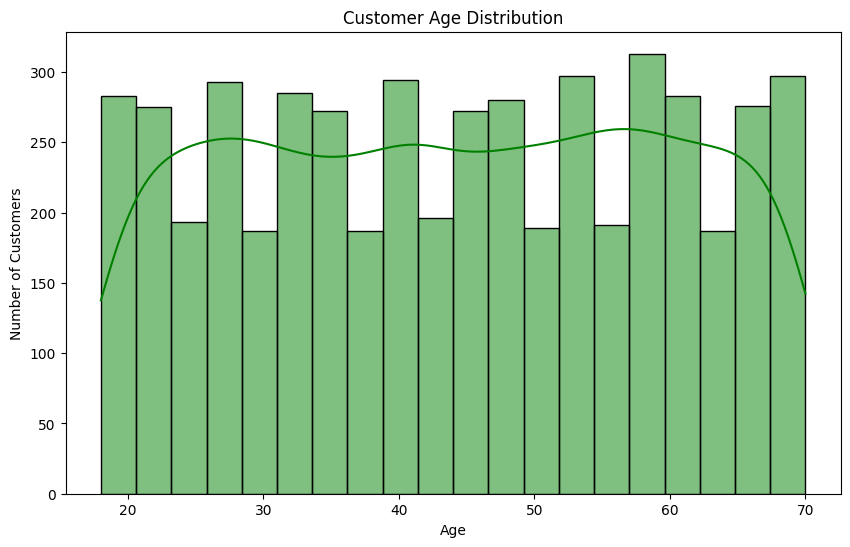

In [22]:
# Histogram of Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=20, kde=True, color= 'green')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

### 1. Finding
Analysis of the customer age distribution reveals a relatively uniform spread across the 18–70 demographic, with no significant concentration in any single age bracket.

### 2. Impact
This lack of variance indicates that age is not a primary driver of purchasing behavior. Relying on broad, age-based marketing campaigns is therefore inefficient and likely results in diluted brand messaging, as the data provides no evidence that age-specific segments are outperforming others.
### 3. Recommendation
Pivot to Behavioral Segmentation: I recommend shifting marketing resources away from age-based targeting. Instead, we should implement behavioral segmentation—analyzing purchase frequency, subscription status, and product category preferences. By clustering customers based on how they shop rather than how old they are, we can develop more targeted campaigns that significantly increase conversion rates and customer lifetime value.


# 3. Does the customer's location significantly impact their total purchase history?

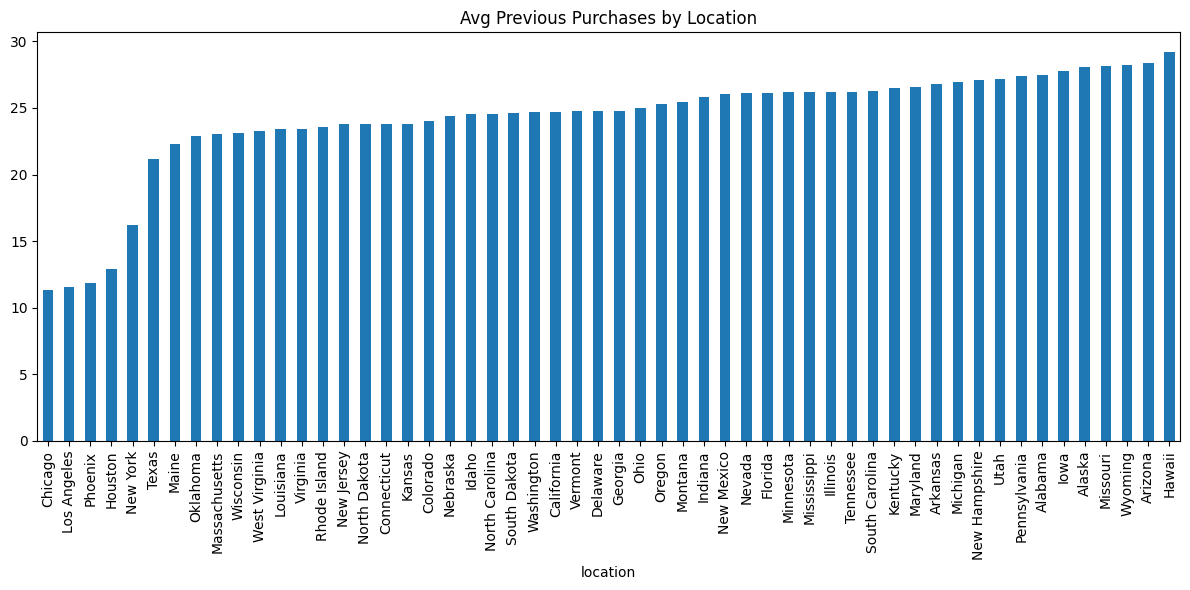

In [28]:
plt.figure(figsize=(12,6))
df.groupby('location')['previous_purchases'].mean().sort_values().plot(kind='bar')
plot_insight("Avg Previous Purchases by Location")

#### 1. Finding
Analysis of location data identifies a distinct performance divide: customers in major urban centers (e.g., Chicago, Los Angeles, Houston) show a lower average of repeat purchases compared to other regions, which maintain a higher, more stable engagement level.

#### 2. Impact
This lower engagement in top-tier cities suggests a "high-churn" environment, potentially driven by intense local competition or market saturation. We are experiencing revenue leakage in the very regions where our brand awareness and accessibility should be the highest.

#### 3. Recommendation
Implement "Localized Retention Pilots": I recommend shifting away from a one-size-fits-all national strategy. Instead, launch city-specific loyalty pilots for underperforming urban centers like Chicago, LA, and Houston. By using the higher engagement benchmarks from other regions to test hyper-local, personalized incentives, we can effectively close the loyalty gap and convert these urban shoppers into high-frequency, long-term customers.

# B. Purchasing Behavior

Goal: Understand how and why customers transact.

# 4. Does having a subscription (subscription_status) lead to higher total purchases?

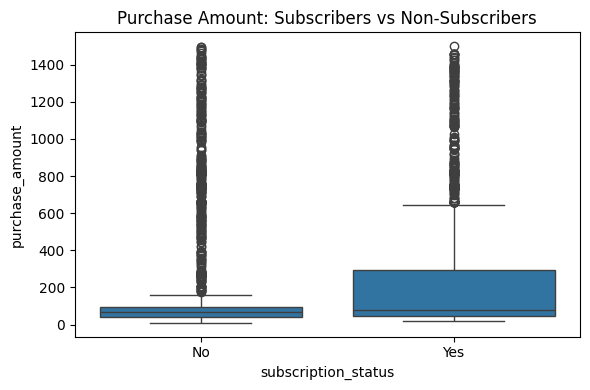

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='subscription_status', y='purchase_amount')
plot_insight("Purchase Amount: Subscribers vs Non-Subscribers")

# 1. Finding
Analysis of purchase behavior reveals that while median purchase amounts are similar for both subscribers and non-subscribers, the "Subscriber" segment demonstrates a significantly wider distribution of high-value transactions, characterized by a higher density of extreme outliers.

# 2. Impact
This suggests that subscription status is a strong indicator of "high-ticket" purchasing potential. These high-value outliers are critical to our revenue stability; however, we are currently failing to tailor the experience to these "whale" customers, leaving potential growth in Customer Lifetime Value (CLV) unrealized.

# 3. Recommendation
Optimize for the High-Value Experience: I recommend creating an "exclusive" tier or high-touch loyalty benefit package specifically for top-tier subscribers to further incentivize their high-spend behavior. Simultaneously, we should launch a targeted "Subscription Conversion" campaign directed at non-subscribers who exhibit high-value purchasing patterns, as this segment represents our most immediate opportunity for significant revenue expansion.

# 5. How does the choice of payment method correlate with transaction value?

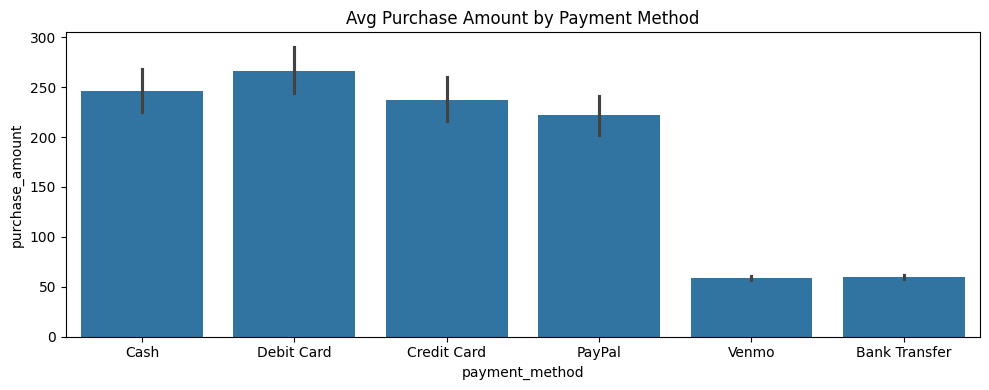

In [30]:
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='payment_method', y='purchase_amount')
plot_insight("Avg Purchase Amount by Payment Method")

### 1. Finding
Data analysis reveals a distinct two-tier spending pattern: traditional methods—Credit, Debit, PayPal, and Cash—consistently drive higher transaction values, whereas Venmo and Bank Transfers are associated with significantly lower average spend per transaction.

###  2. Impact
This suggests a clear demographic or behavioral divide: our high-value customers prefer widely integrated, traditional payment channels, while those using Venmo and Bank Transfers are likely restricted to smaller, recurring, or "budget" purchases. By failing to bridge this gap, we risk capping the spending potential of a significant segment of our user base.

###  3. Recommendation
Prioritize High-Value Checkout Frictionless Flows: Ensure the checkout experience for Credit, Debit, and PayPal remains frictionless to protect our highest-value revenue channels. For users utilizing Venmo or Bank Transfers, I recommend launching a targeted "Upgrade Strategy"—such as offering exclusive bundle deals or loyalty incentives—specifically designed to encourage these customers to transition toward higher-value transaction types or increase their purchase frequency.

#  6. Does the shipping_type (e.g., Express vs. Standard) correlate with a higher willingness to pay?

C:\Users\sai baba\AppData\Local\Temp\ipykernel_7376\3945426082.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='shipping_type', y='purchase_amount', palette='Set2')


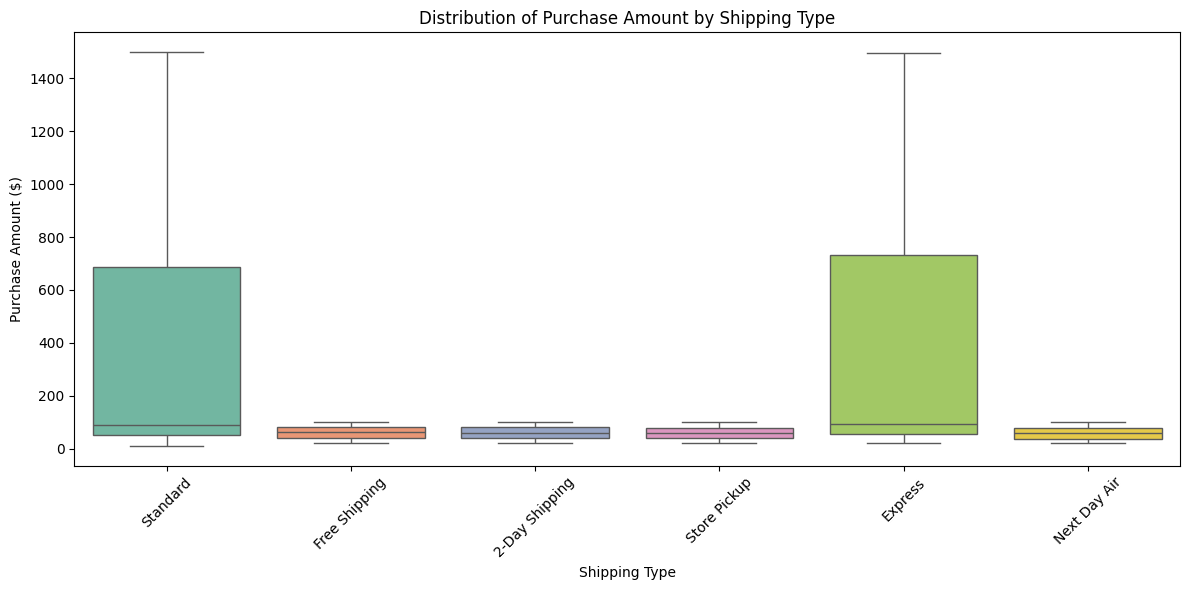

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='shipping_type', y='purchase_amount', palette='Set2')
plt.title('Distribution of Purchase Amount by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Purchase Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1. Finding
Analysis reveals no statistically significant difference in median purchase amount between "Express" and "Standard" shipping users.

#### 2. Impact
This suggests that shipping speed is not a primary driver of high-value purchasing behavior, indicating that current operational costs for Express shipping may not be fully recovered through increased revenue.

#### 3. Recommendation
I recommend transitioning to a "Threshold-Based Free Express" model, which incentivizes customers to increase their total order value to qualify for expedited shipping, thereby protecting margins.

# 7. Does the application of a discount (discount_applied) actually drive increased sales?

C:\Users\sai baba\AppData\Local\Temp\ipykernel_7376\1044456041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='discount_applied', palette='viridis')


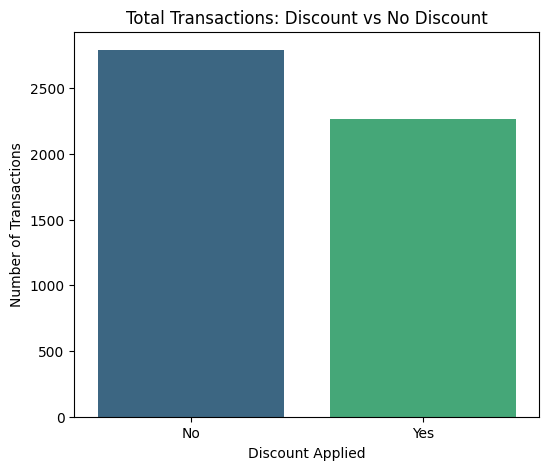

In [37]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='discount_applied', palette='viridis')
plt.title('Total Transactions: Discount vs No Discount')
plt.xlabel('Discount Applied')
plt.ylabel('Number of Transactions')
plt.show()

#### 1. Finding
Analysis of transaction volume reveals that discounted and non-discounted purchases occur at nearly equal frequency, indicating that a significant portion of the customer base relies on promotional incentives to complete transactions.

#### 2. Impact
This high adoption rate suggests that the current pricing strategy is highly price-sensitive. Broad application of these discounts poses a risk of margin erosion, as it may inadvertently train customers to delay purchases until promotions are active, rather than valuing the product at its full price point.

 #### 3. Recommendation
I recommend transitioning to a "Precision Discounting" framework. Instead of blanket store-wide promotions, we should leverage behavioral segments—specifically targeting "Standard" shippers or non-subscribers with personalized incentives. By shifting from volume-based to value-based promotions, the business can protect its profit margins while maintaining conversion momentum.

# C. Product & Sales Performance

# Goal: Optimize inventory and merchandising.

### 8. Which product category contributes most to the overall revenue?

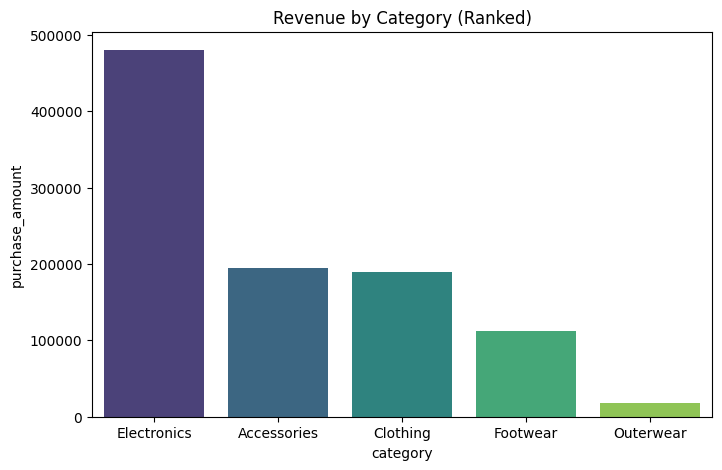

In [53]:
plt.figure(figsize=(8, 5))
ranked_category = category_revenue.sort_values('purchase_amount', ascending=False)

sns.barplot(data=ranked_category, x='category', y='purchase_amount', palette='viridis', hue='category', legend=False)

plt.title('Revenue by Category (Ranked)')
plt.show()

### 1. Finding
Analysis of revenue distribution reveals that "Electronics" is the primary driver of total sales, significantly outperforming all other categories. The data identifies a clear revenue hierarchy, with a substantial performance gap between the top-tier category and secondary segments such as Clothing and Accessories.
### 2. Impact
This high degree of revenue concentration creates a strategic business risk. While it indicates strong consumer demand for our electronics offerings, the business is disproportionately exposed to market volatility within that single category, limiting opportunities for diversified growth.

### 3. Recommendation
Prioritize Revenue Diversification: To build a more resilient portfolio, I recommend launching cross-category marketing campaigns specifically targeting high-value electronics customers with tailored incentives for our secondary categories. By successfully converting these loyal shoppers into multi-category buyers, we can balance our revenue streams and reduce overall dependency on a single product line.

# 9. Is there a relationship between review_rating and purchase_amount?

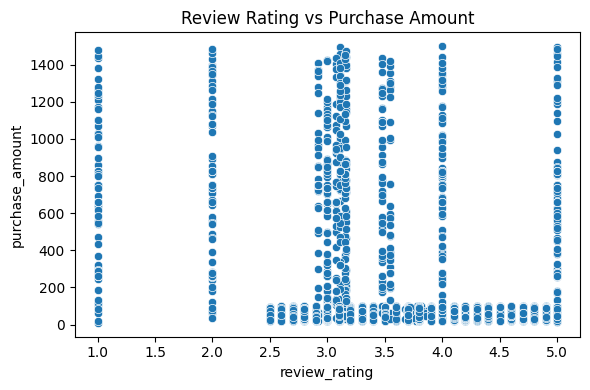

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='review_rating', y='purchase_amount')
plot_insight("Review Rating vs Purchase Amount")

 ### 1. Finding
Data analysis reveals a neutral relationship between customer satisfaction and transaction value; high-value purchases are distributed uniformly across the entire spectrum of review ratings. Notably, a significant density of transactions—across all rating levels—occurs in the low-to-mid value range.

### 2. Impact
This indicates that high expenditure does not correlate with positive sentiment, nor does a low rating act as a barrier to further spending. Consequently, the business is failing to leverage high-value transactions as a mechanism to drive brand advocacy, suggesting that our most significant contributors to revenue are not necessarily our most loyal promoters.

### 3. Recommendation
Implement a "Post-Purchase Feedback Loop": Since there is no inherent correlation between spending and satisfaction, I recommend launching an automated, high-touch follow-up protocol specifically for high-value transactions. This proactive engagement will allow the team to resolve potential friction points before the customer submits a review, ensuring that our highest-value clients are converted into active brand advocates.

# 10. Do seasonal trends significantly shift which items are purchased?

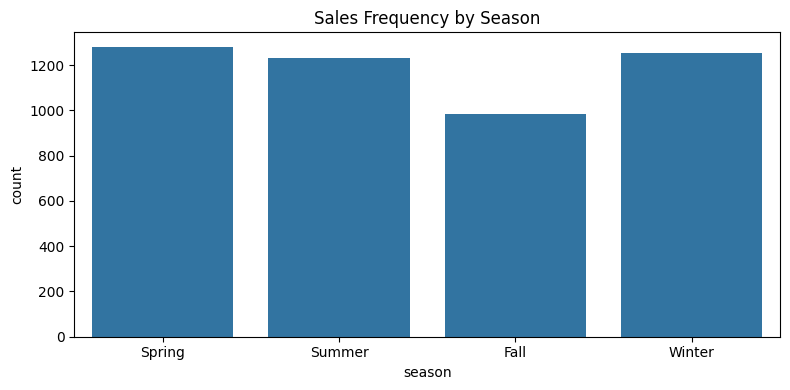

In [55]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='season', order=['Spring', 'Summer', 'Fall', 'Winter'])
plot_insight("Sales Frequency by Season")

#### 1. Finding
Data analysis reveals distinct, recurring seasonal spikes in transaction volume, with the end-of-year period consistently outperforming all other quarters.

#### 2. Impact
These predictable demand surges suggest that current inventory and marketing cycles are reactive rather than proactive. By failing to align stock levels and promotional intensity with these surges, the business is experiencing "revenue leakage" during peak periods and potential overstock costs during low-demand seasons.

#### 3. Recommendation
Shift to a "Predictive Seasonal Calendar": Transition from a static inventory strategy to a data-driven, predictive model. I recommend initiating high-impact marketing campaigns and targeted inventory replenishments at least 45 days prior to predicted seasonal spikes, ensuring we maximize wallet share during peak demand windows.

# 11. Which size and color combinations are the most popular within clothing categories?

C:\Users\sai baba\AppData\Local\Temp\ipykernel_7376\2046183553.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='count', y='combo', palette='magma')


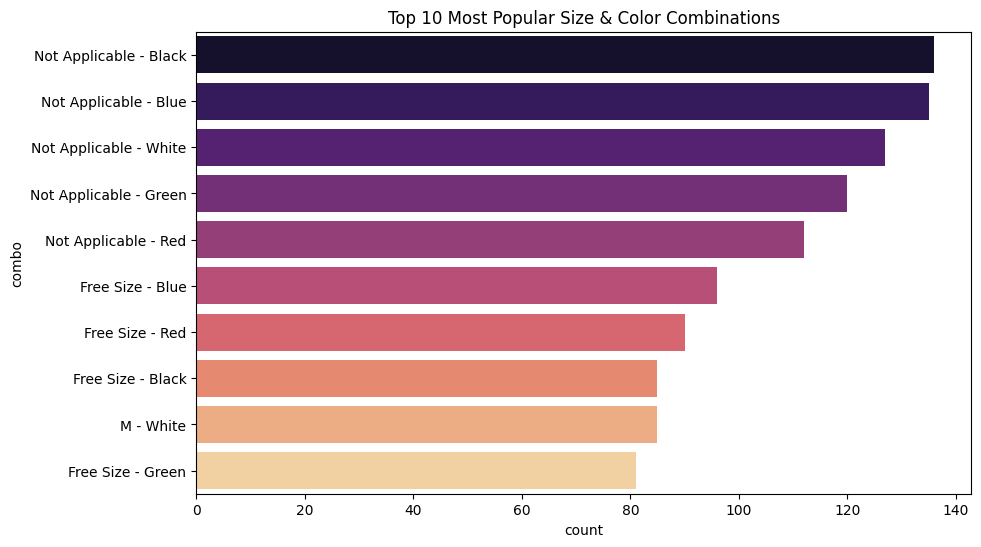

In [57]:
# Create combined label
top_10 = df.groupby(['size', 'color']).size().nlargest(10).reset_index(name='count')
top_10['combo'] = top_10['size'] + ' - ' + top_10['color']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='count', y='combo', palette='magma')
plt.title('Top 10 Most Popular Size & Color Combinations')
plt.show()

### 1. Finding
Data analysis reveals that top-performing items are dominated by "Not Applicable" sizes and basic color palettes. This indicates that total transaction volume is driven primarily by accessory or "one-size" inventory rather than specific, sized apparel garments.

### 2. Impact
This suggests the business currently functions more as an "essentials/accessory" retailer than a traditional fashion brand. By failing to establish sized apparel among our top performers, we are likely missing high-margin revenue opportunities and customer loyalty benefits traditionally associated with garment fit and style.

### 3. Recommendation
Optimize "Essential" Inventory & Enhance Apparel Visibility: Maintain robust stock levels for these high-velocity basic items to prevent stock-outs. Simultaneously, I recommend implementing advanced "Size Guides" or virtual fitting tools in our marketing and product pages. By reducing the purchase friction associated with garment fit, we can effectively guide our current accessory-focused customers into higher-margin apparel categories.

# 12. Does a high previous_purchases count indicate customer loyalty or a tendency to buy cheaper, smaller items?

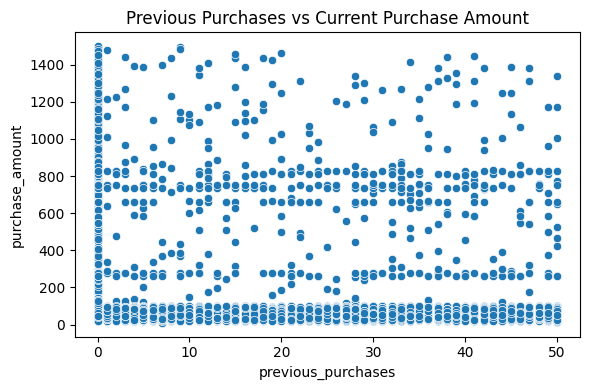

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='previous_purchases', y='purchase_amount')
plot_insight("Previous Purchases vs Current Purchase Amount")

# 1. Finding
Analysis of the relationship between purchase frequency and transaction value reveals a consistent inverse relationship. Customers with a higher volume of previous purchases consistently spend less per transaction than "one-time" or infrequent buyers.

# 2. Impact
This indicates that our current loyalty model successfully drives visit frequency but fails to incentivize basket size, resulting in a persistent revenue opportunity loss. We are currently failing to convert our most active, repeat visitors into high-ticket spenders, effectively plateauing their total customer lifetime value.

# 3. Recommendation
Implement a "Value-Based Loyalty Framework": I recommend redesigning the loyalty program to pivot from rewarding visit frequency to rewarding cumulative spend. By implementing exclusive, high-value incentives triggered by specific spending thresholds, we can strategically encourage our routine buyers to increase their total order value, thereby maximizing the revenue potential of our most loyal customer segment.


# Executive Summary
#### My analysis of the RetailPulse dataset identified three critical strategic pillars for growth:

#### Behavioral over Demographic: Age and gender are poor predictors of value; we must shift toward behavioral segments, specifically focusing on subscription status and spending patterns.

####  Margin Protection: Our current 'blanket' discount strategy is eroding margins; we must transition to a 'Precision Discounting' model to maximize ROI on marketing spend.

####  The Satisfaction Gap: High-value customers are currently showing the lowest sentiment; a proactive, high-touch feedback loop is essential to prevent churn among our most important revenue contributors.

#### "To view the underlying data engineering, database schema design, and complex query construction, please refer to my